In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import matplotlib.pyplot as plt
import random
random.seed(42)

pd.set_option('display.max_columns', None)

In [78]:
def wrangle(df, shop_id, sku_id=None, split_days=7):
    
    # ── Convert date ─────────────────────────────────────────────
    df["date"] = pd.to_datetime(df["date"])

    # ── Filter data ─────────────────────────────────────────────
    if sku_id is not None:
        df_filtered = df[
            (df["customer_code"] == shop_id) & 
            (df["sku_code"] == sku_id)
        ].copy()
    else:
        df_filtered = df[
            df["customer_code"] == shop_id
        ].copy()

    # Safety check
    if df_filtered.empty:
        raise ValueError(f"No data found for shop_id={shop_id}, sku_id={sku_id}")

    # ── Aggregate: sales per day ─────────────────────────────────
    df_daily = (
        df_filtered
        .groupby("date", as_index=False)["sales_quantity"]
        .sum()
        .sort_values("date")
    )

    # ── Create full date range ───────────────────────────────────
    full_dates = pd.date_range(
        start=df_daily["date"].min(),
        end=df_daily["date"].max(),
        freq="D"
    )

    # ── Reindex to fill missing dates ────────────────────────────
    median_val = df_daily["sales_quantity"].median()

    df_daily = (
        df_daily
        .set_index("date")
        .reindex(full_dates)
        .fillna(median_val)   # 👈 fill with median
        .rename_axis("date")
        .reset_index()
    )

    # ── Prepare for Prophet ──────────────────────────────────────
    df_prophet = df_daily.rename(columns={
        "date": "ds",
        "sales_quantity": "y"
    })

    # ── Train-test split ─────────────────────────────────────────
    split_date = df_prophet["ds"].max() - pd.Timedelta(days=split_days)

    df_train = df_prophet[df_prophet["ds"] <= split_date].copy()
    df_test = df_prophet[df_prophet["ds"] > split_date].copy()

    return df_train, df_test, df_prophet

In [79]:
def top_n_customers_sku(df, top_n=10):
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    top_customer_ids = top_customers.index

    df_top_customers = df[df["customer_code"].isin(top_customer_ids)]

    top_sku_per_customer = (
        df_top_customers
        .groupby(["customer_code", "sku_code"])["sales_quantity"]
        .sum()
        .reset_index()
        .sort_values(["customer_code", "sales_quantity"], ascending=[True, False])
        .groupby("customer_code")
        .head(1)
    )

    return top_sku_per_customer

In [80]:
def top_n_customer_sales(df, n=5):
    # Find the top 10 customer.
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(n)
    )

    return top_customers

In [81]:
def train_prophet(df_train):
    model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    model.fit(df_train)
    return model

In [82]:
def evaluate(forecast, df_test):
    forecast_test = forecast[forecast["ds"].isin(df_test["ds"])]
    eval_df = df_test.merge(
        forecast_test[["ds", "yhat"]],
        on="ds",
        how="left"
    )

    mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])
    rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}, eval_df

In [83]:
def plot_results(eval_df, shop_id, sku_id):
    plt.figure(figsize=(12, 6))
    plt.plot(eval_df["ds"], eval_df["y"], label="Actual", marker='o')
    plt.plot(eval_df["ds"], eval_df["yhat"], label="Predicted", marker='x')
    plt.title(f"Actual vs Predicted Sales Quantity for Shop {shop_id} and SKU {sku_id}")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show();

In [84]:
df_path = "../../../../data/France/processed_data/sell_out_merged.csv"
df = pd.read_csv(df_path)
df['date'] = pd.to_datetime(df['date'])
df.rename(columns={"territory_id": "route","territory_name": "route_name","Volume in Unit": "sales_quantity","Volume in Packs": "sales_amount",},inplace=True,)

In [85]:
top_sku_per_customer = top_n_customers_sku(df=df, top_n=5)

In [86]:
top_n_customers = top_n_customer_sales(df, 5)

In [87]:
top_n_customers.index.tolist()

[301097.0, 300005.0, 304032.0, 306055.0, 302198.0]

22:36:32 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 301097 ...


22:36:32 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 301097: {'MAE': 514.4530225915444, 'MAPE': 0.04185795449260514, 'RMSE': 546.5729653123534}


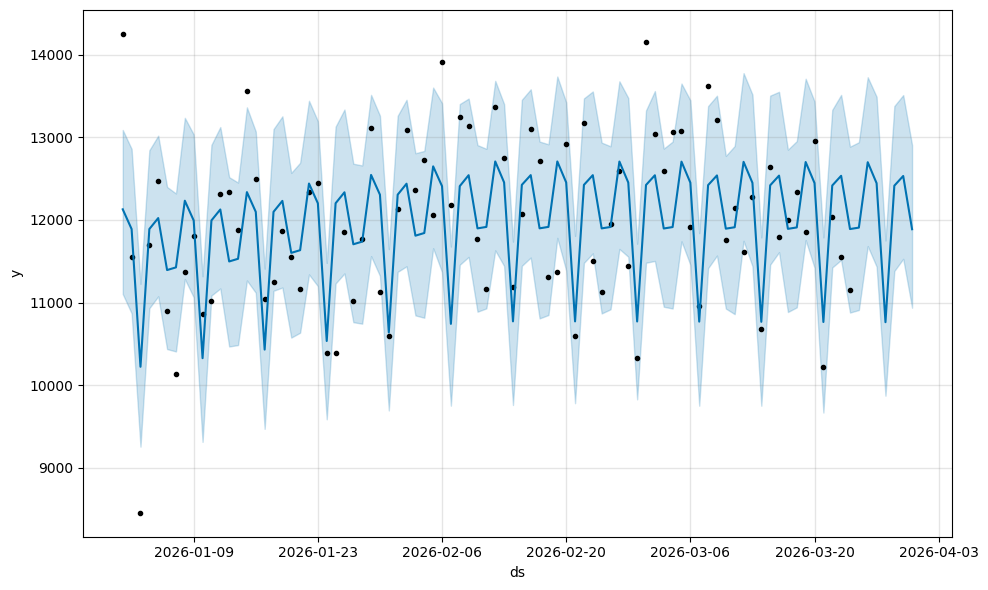

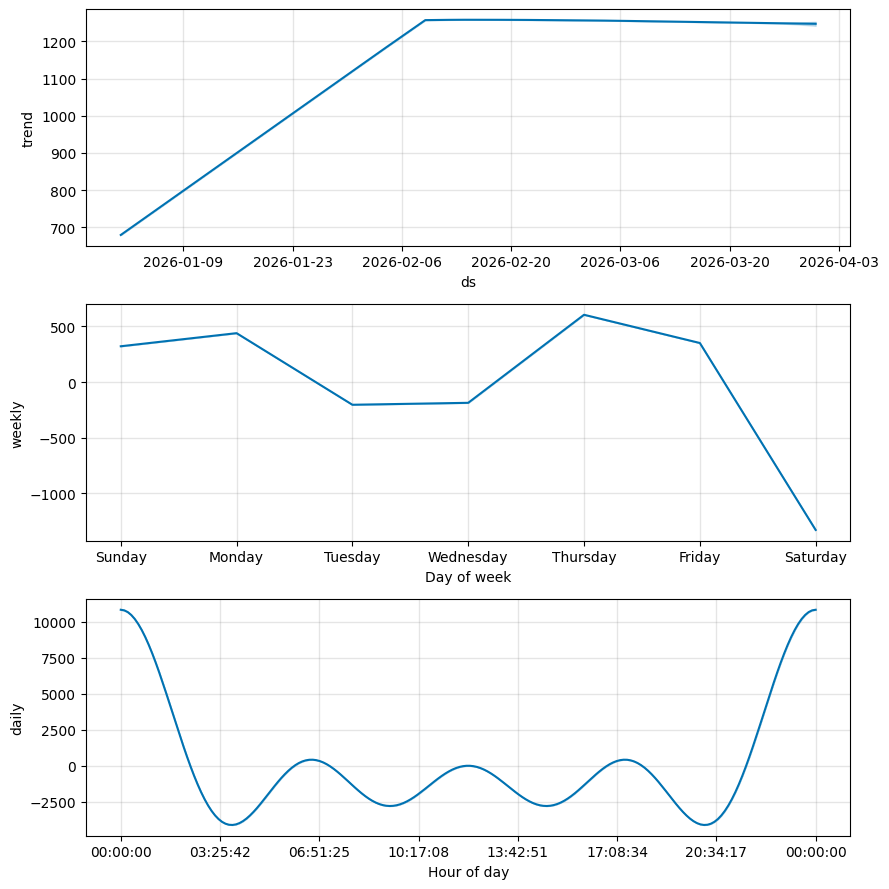

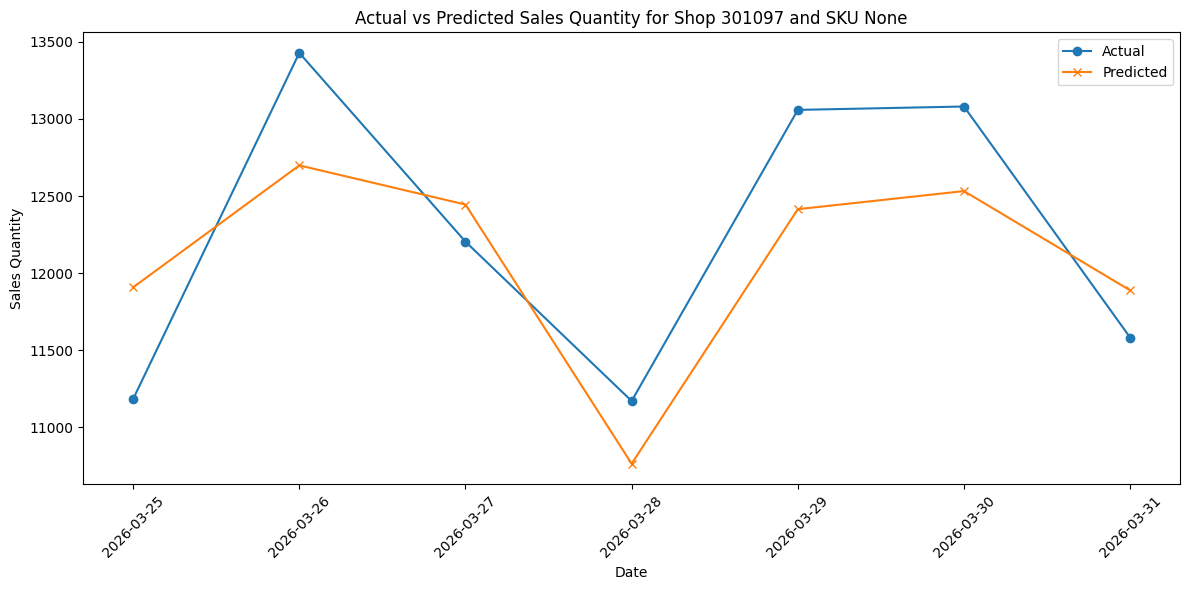

22:36:34 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 300005 ...


22:36:34 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 300005: {'MAE': 6112.258311063806, 'MAPE': 0.31773813052413374, 'RMSE': 6251.052199806701}


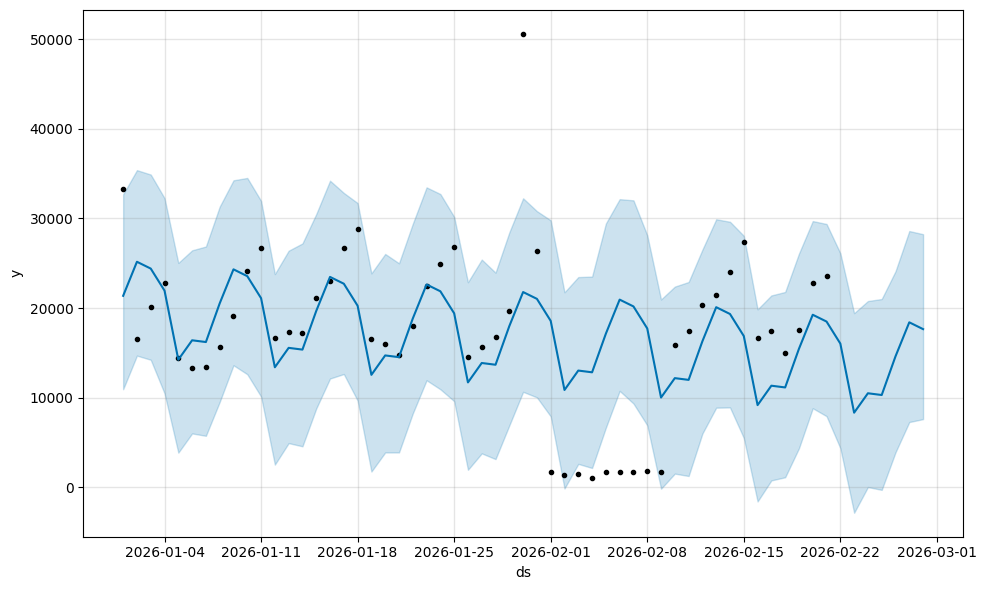

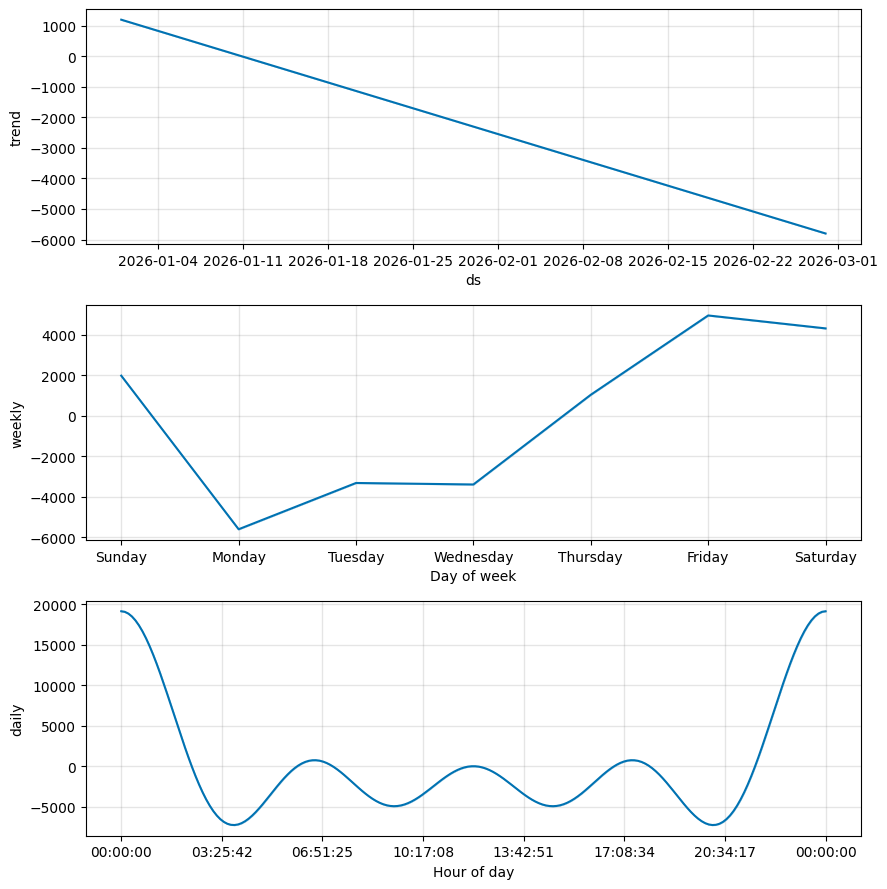

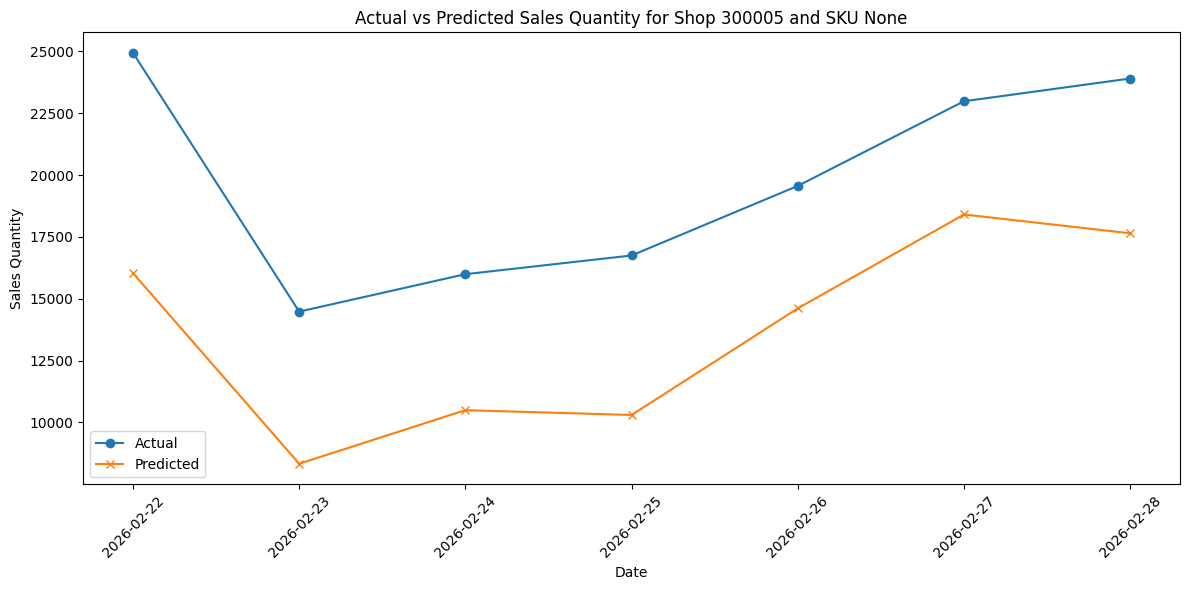

22:36:36 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 304032 ...


22:36:36 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 304032: {'MAE': 667.2235846609207, 'MAPE': 0.06299677264869147, 'RMSE': 777.9095006257033}


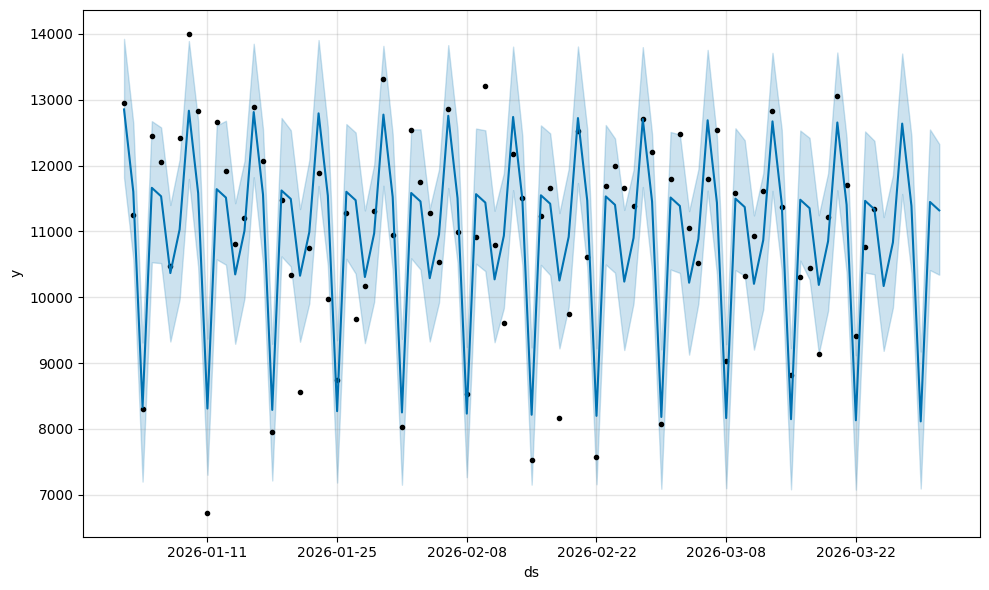

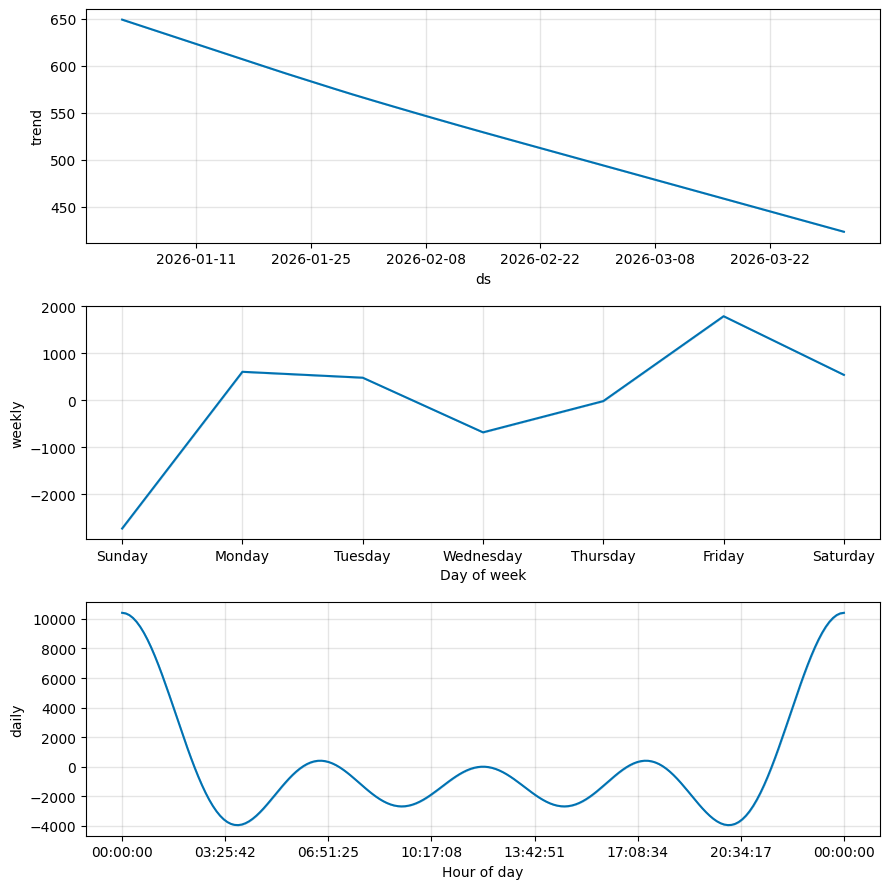

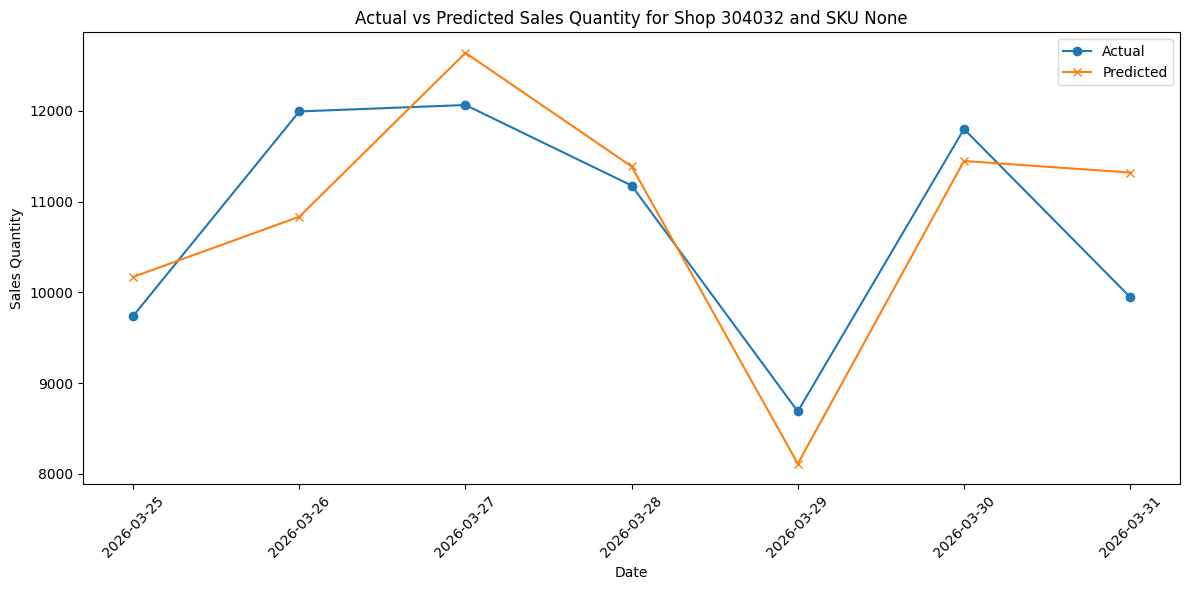

22:36:37 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 306055 ...


22:36:38 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 306055: {'MAE': 908.9118940698439, 'MAPE': 0.07576851551228346, 'RMSE': 1195.0719092913237}


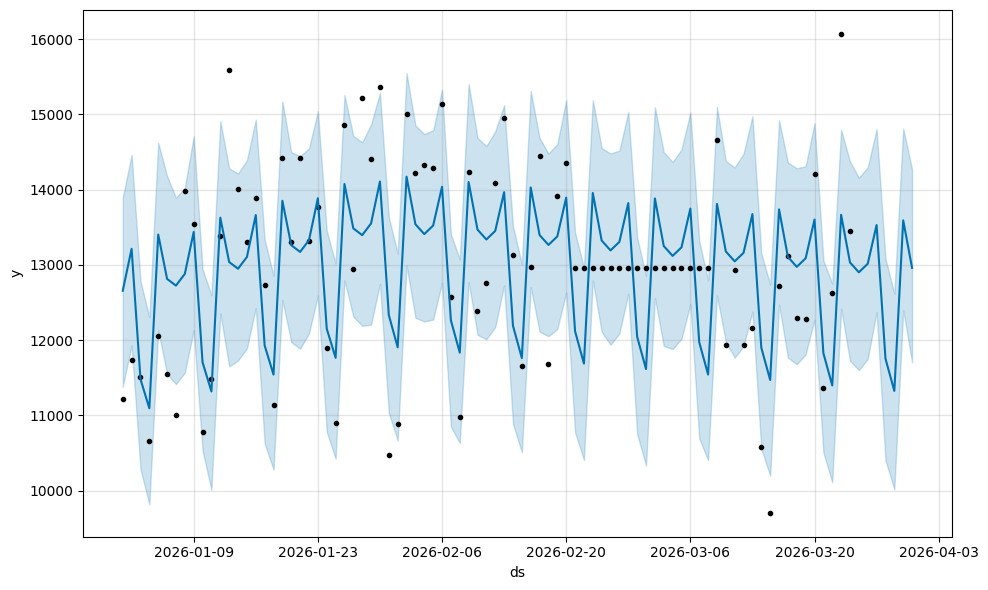

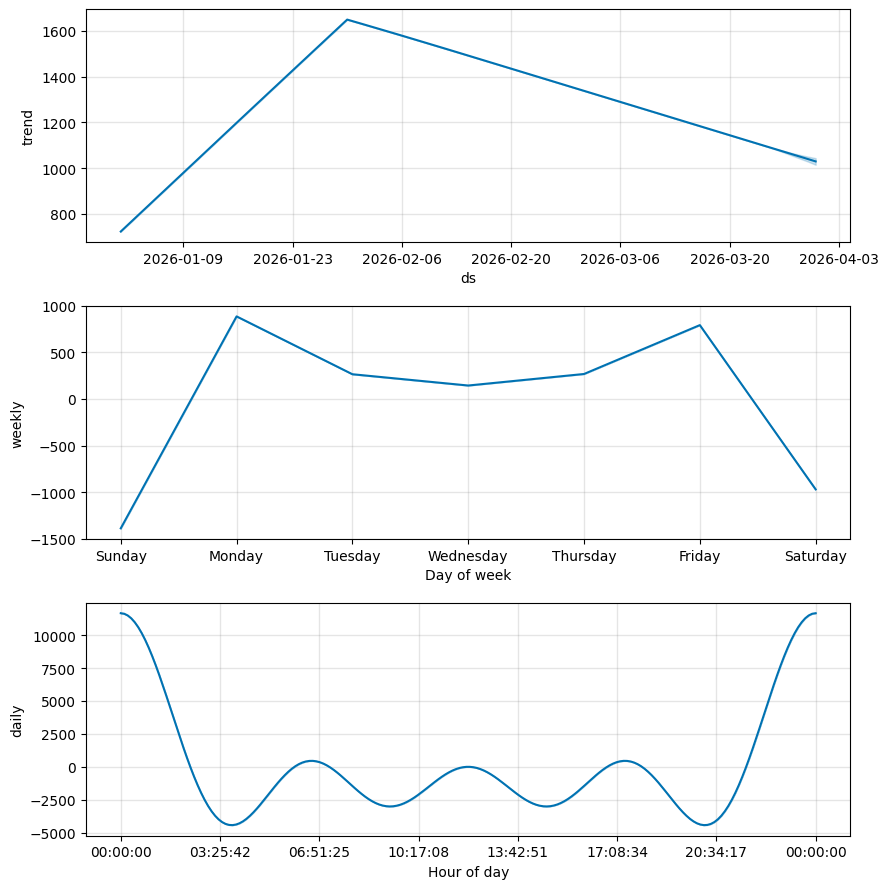

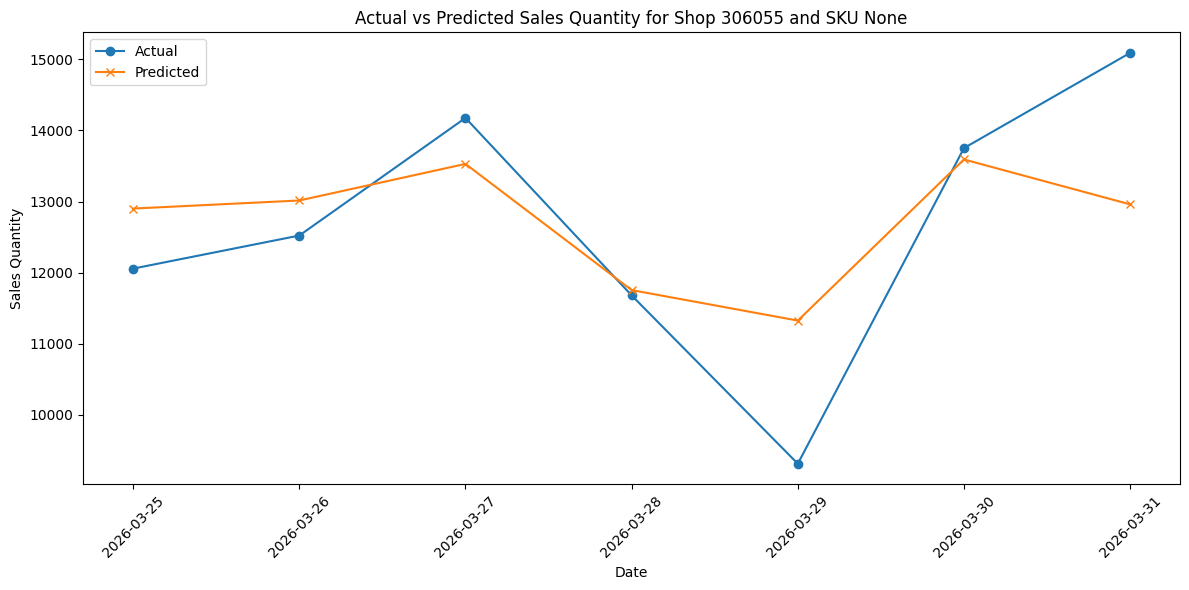

22:36:39 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 302198 ...


22:36:40 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 302198: {'MAE': 1098.1509062603504, 'MAPE': 0.1653554215942283, 'RMSE': 1464.709080557879}


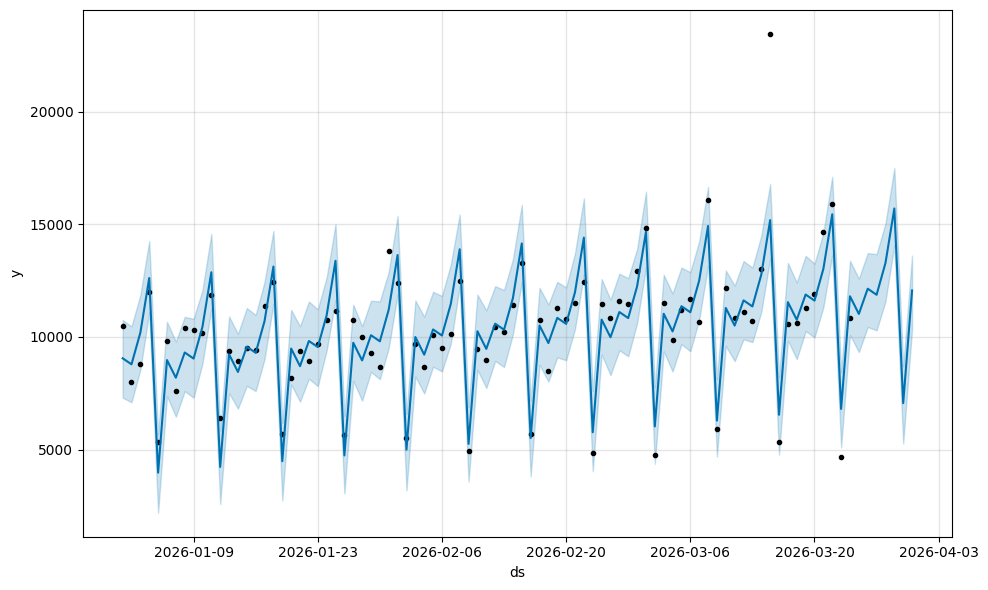

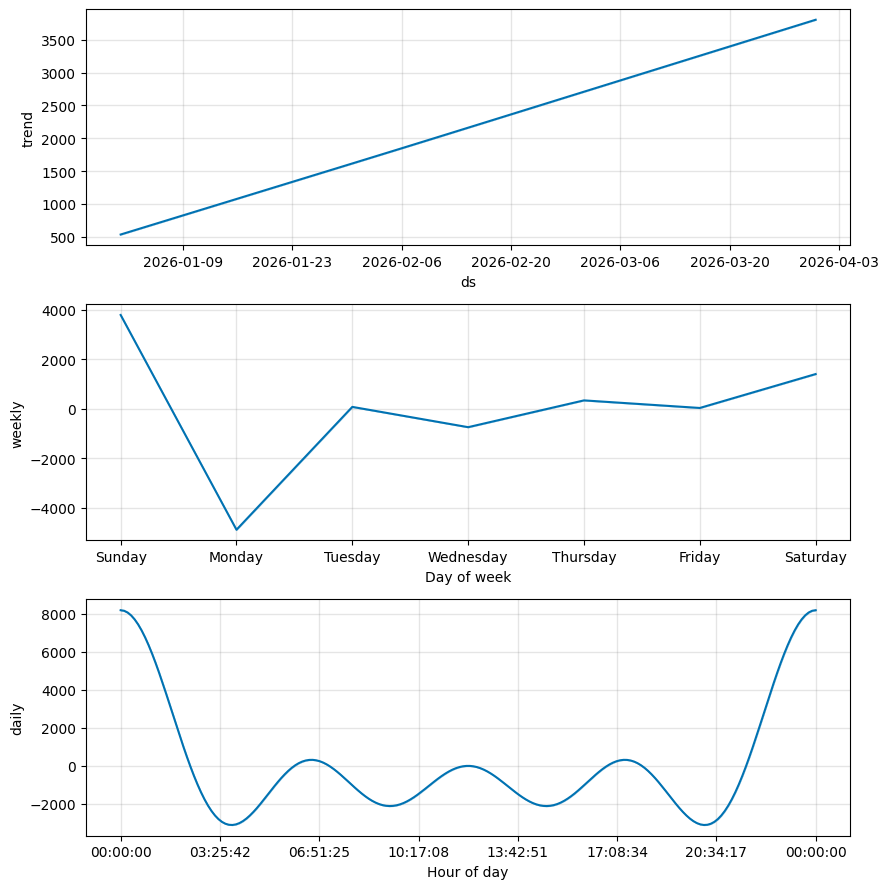

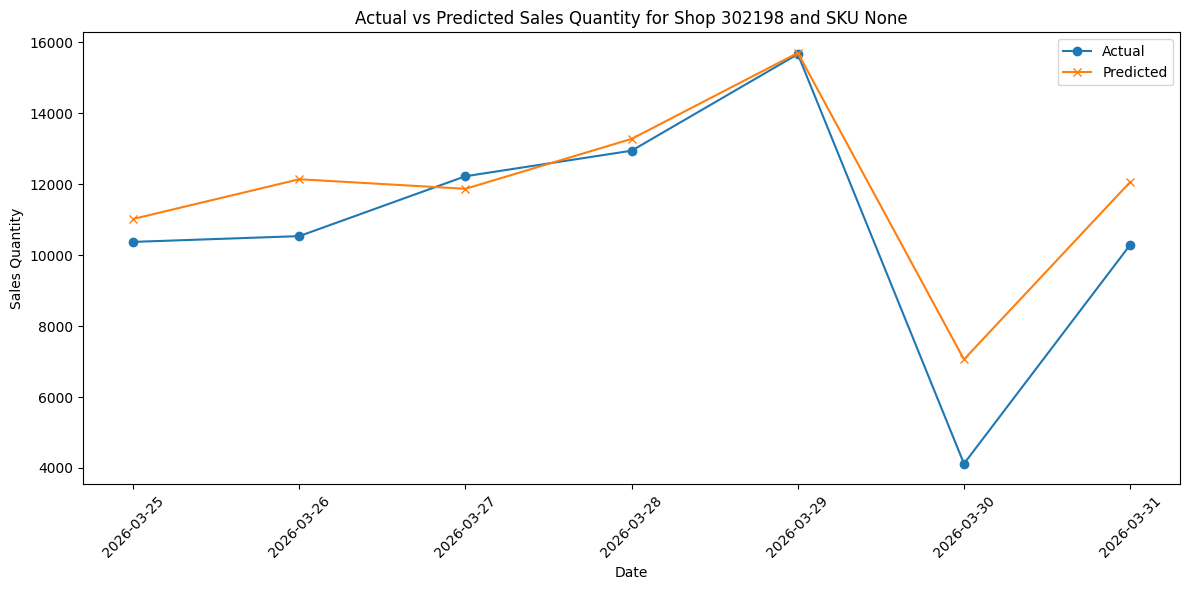

In [88]:
for i in top_n_customers.index.tolist():
    shop_id = int(i)

    print(f"Processing Customer {shop_id} ...")

    df_train, df_test, df_prophet = wrangle(df, shop_id=shop_id)

    model = train_prophet(df_train)

    future = model.make_future_dataframe(periods=len(df_test))
    forecast = model.predict(future)

    results, eval_df = evaluate(forecast, df_test)
    print(f"Results for Customer {shop_id}: {results}")

    model.plot(forecast)
    model.plot_components(forecast)

    plot_results(eval_df, shop_id, sku_id=None)